# 🎓 The Academic Predictor: Master Student Workbook
**Student Name:** Inigo Diaz

Welcome to your Final Project! This notebook contains all the requirements for your HSC submission. Work through this notebook sequentially. You must write the Python code yourself based on the lessons we completed in class.

---
### ⚙️ Setup: Library Installation
Run the cell below first to instantly install the required AI libraries.

In [21]:
!pip install --prefer-binary pandas numpy scikit-learn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


print("\n✅ All libraries successfully installed and imported!")


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

✅ All libraries successfully installed and imported!


---
## Phase 1: Data Automation
**🎯 The Goal:** You must use Pandas to load `master_markbook.csv` and clean it. Machine Learning algorithms will crash if they encounter missing data (`NaN`). Furthermore, an AI will learn incorrect mathematical patterns if it is trained on impossible data (like scores below 0 or above 100).

**📄 Documentation Task:** Create a new Markdown cell below your code. Add the heading `### Data Cleaning Strategy`. Underneath, explicitly list the three types of "dirty data" you fixed: 1. Missing values, 2. Negative scores, and 3. Scores over 100. Explain why cleaning this is legally and ethically important.

**📊 PPT Slide Task:** Create a slide titled "Data Strategy". Take a screenshot of the raw CSV showing a corrupted row (e.g., someone with -50 or 200). Put it next to a screenshot of your cleaned Pandas dataframe. Add bullet points explaining that "Garbage Data In = Garbage AI Predictions Out."

In [3]:
print("--- Loading and Cleaning Data ---")

# Prints the full DataFrame without truncation (for debugging purposes)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Loads the raw dataset into a variable called 'df_raw'
df_raw = pd.read_csv('master_markbook.csv', sep=',', encoding='latin-1') # sep=',' means comma-separated | encoding='latin-1' avoids Unicode errors
# Prints the length (number of rows) of 'df_raw' to know the starting number.
print(len(df_raw))
df_raw
# Creates a new variable called 'df_clean.' and the Pandas '.dropna()' method to clean the database.
df_clean = df_raw.dropna()
# Updates 'df_clean' by filtering it (Only keep rows where marks are .between(0, 100).)
df_clean = df_clean[df_clean['Maths_Advanced'].between(0, 100) & df_clean['Physics'].between(0, 100) & df_clean['Software_Engineering_Final'].between(0, 100)]
# Prints the length of df_clean. (Database should have fewer rows than before)
print(len(df_clean))
df_clean



--- Loading and Cleaning Data ---
28
21


,Student_Name,Maths_T1,Maths_T2,Maths_T3,Maths_T4,Maths_Advanced,Phys_T1,Phys_T2,Phys_T3,Phys_T4,Physics,Hist_T1,Hist_T2,Hist_T3,Hist_T4,Modern_History,Software_Engineering_T1,Software_Engineering_T2,Software_Engineering_T3,Software_Engineering_T4,Software_Engineering_Final
0,Alice Adams,23,22,24.0,23,92.0,21,23.0,22,23,89.0,15,14,16,15.0,60.0,22.0,24,23,22,91.0
1,Ben Brown,24,24,23.0,25,96.0,23,24.0,25,24,96.0,22,24,23,23.0,92.0,24.0,25,24,24,97.0
2,Chloe Chen,12,14,13.0,15,54.0,14,15.0,14,15,58.0,23,22,24,23.0,92.0,11.0,12,10,11,44.0
3,Daniel Diaz,18,17,19.0,18,72.0,17,18.0,19,16,70.0,18,17,19,18.0,72.0,18.0,19,17,18,72.0
4,Emma Evans,20,21,20.0,22,83.0,21,20.0,22,19,82.0,16,17,18,16.0,67.0,21.0,22,20,22,85.0
5,Finn Fisher,10,12,11.0,12,45.0,11,10.0,12,11,44.0,12,14,13,12.0,51.0,11.0,12,11,13,47.0
6,Grace Garcia,17,18,16.0,17,68.0,16,17.0,18,16,67.0,19,18,20,19.0,76.0,17.0,18,16,18,69.0
7,Henry Hall,22,23,21.0,22,88.0,23,22.0,24,22,91.0,14,15,13,16.0,58.0,22.0,23,22,21,88.0
8,Ivy Irwin,14,13,15.0,14,56.0,12,14.0,13,14,53.0,24,23,25,24.0,96.0,12.0,11,12,11,46.0
9,Jack Jones,19,19,18.0,19,75.0,18,19.0,20,18,75.0,17,18,17,19.0,71.0,19.0,18,19,20,76.0


### Data Cleaning Strategy

1. **Missing Values:**
  Victor Vance - Maths_T3, Yara Young - Physics_T2, Zane Zane - History_T4, Alex Anderson - Software_Engineering_T1
2. **Negative Scores:**
  Xena Xie - Physics, Amy Ames - Software Engineering
3. **Scores Over 100:**
  Will White - Maths_Advanced

Cleaning this database is legally and ethically important because it would effectively protect sensitive data which protects the privacy of personal data from students. Additionally, it woudl imporve accuracy and fairness by removing invalid values, whilst reducing risks of biased analysis.

---
## Phase 2: The Baseline AI
**🎯 The Goal:** Build a basic AI (Linear Regression) that predicts the final Software Engineering mark using only **one** input subject (Maths_Advanced). You must split your data into Training (80%) and Testing (20%) sets so the AI cannot "cheat" by memorizing the test answers.

**📄 Documentation Task:** Add a Markdown cell below. Write the heading `### The ML Pipeline`. List and define the 5 stages of Machine Learning (Define, Collect, Prepare, Train, Evaluate) in the context of this specific school project.

**📊 PPT Slide Task:** Create a slide titled "The Problem". Introduce your chosen student (Alex, Victor, Yara, or Zane) and explain their missing assessment. Add a graphic showing how you divided the class data into an 80% Training block and a 20% Testing block.

In [38]:
print("--- Training Level 1 AI ---")

# Creates a variable X1 and sets it to df_clean[['Maths_Advanced']].values
X1 = df_clean[['Maths_Advanced']].values
# Creates a variable y and sets it to df_clean['Software_Engineering_Final'].values
y = df_clean['Software_Engineering_Final'].values
# 'train_test_split()' function to divide X1 and y. Sets test_size value as 0.2 and random_state as 42.
X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)
# Initialize a LinearRegression() model.
acad_pred = LinearRegression()
# '.fit()' the model using the training data only.
acad_pred.fit(X1_train, y_train)
# Uses model to .predict() the outcomes for test data.
predictor = acad_pred.predict(X1_test)
# Calculates the RMSE (Root Mean Squared Error) by comparing predictions against the real y_test values.
mse  = mean_squared_error(y_test, predictor)
rmse = np.sqrt(mse)
# Prints result
print(f"   Test RMSE = {rmse:.2f} marks") # rounds to 2 decimal places (floats)
print(f"   This means the AP is typically off by about ±{rmse:.1f} marks.") # rounds to 1 decimal place (floats)
print(y_test)
print(X1_train)


--- Training Level 1 AI ---
   Test RMSE = 4.49 marks
   This means the AP is typically off by about ±4.5 marks.
[91. 93. 87. 97. 46.]
[[45.]
 [98.]
 [72.]
 [72.]
 [52.]
 [60.]
 [54.]
 [75.]
 [43.]
 [83.]
 [44.]
 [88.]
 [68.]
 [80.]
 [84.]
 [68.]]


### The ML Pipeline

| Stage | What happens | Relevance to the AP |
|---|---|---|
| **1. Define** | Decide the problem to solve | **Predicting Alex's score** for an exam she missed (i.e. Software) |
| **2. Collect** | Gather the data (i.e. student scores) | **Extract the database** of the cohrot of subjects and student scores |
| **3. Prepare** | Clean the data (remove errors, fill missing values) | **Removing any invalid scores** so the data is clean|
| **4. Train** | Let the AI learn from the data (`.fit()`) | **Creation of 'acad_pred'** that is used to be trained |
| **5. Evaluate** | Test the AI on data it has **never seen before** | Using the database for 'acad_pred' to **predict** |

---
## Phase 3: Mathematical Proof
**🎯 The Goal:** Machine Learning is not magic; it is just geometry. You must extract the specific linear equation ($y = wx + b$) that your AI learned from the dataset and visualize it on a scatter plot.

**📄 Documentation Task:** Create a Markdown cell. Write down the exact mathematical formula your AI generated. (e.g., `Software_Engineering_Final = [Your Weight] * Maths_Advanced + [Your Bias]`). Write a sentence explaining what the weight actually means in plain English (e.g., "For every 1 extra mark a student gets in Maths, their Software score increases by X marks").

**📊 PPT Slide Task:** Create a slide titled "The Mathematical Proof". Insert your generated Matplotlib scatter plot. Point an arrow to the red line and explain to your audience that this line represents the AI's algorithm.

--- Extracting the Formula ---
   Final formula: Software_Engineering_Final = 1.02 * Maths_Advanced + -1.36


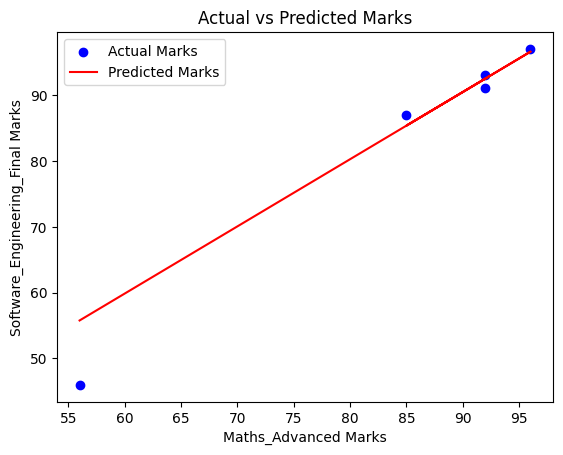

In [6]:
print("--- Extracting the Formula ---")

# Extract the weight using acad_pred.coef_[0] and the bias using acad_pred.intercept_
weight = acad_pred.coef_[0]
bias = acad_pred.intercept_
# Prints out the final formula using those two numbers.
print(f"   Final formula: Software_Engineering_Final = {weight:.2f} * Maths_Advanced + {bias:.2f}")
# Uses plt.scatter() to plot the X1_test data against the y_test data. Make the dots blue.
plt.scatter(X1_test, y_test, color='blue', label='Actual Marks')
# Uses plt.plot() to draw a line mapping X1_test against AP's predictions.
plt.plot(X1_test, predictor, color='red', label='Predicted Marks') # Makes the colour of the line red.
# TODO 5: Add a title, xlabel, ylabel, and plt.show() to display the graph.
plt.title('Actual vs Predicted Marks')
plt.xlabel('Maths_Advanced Marks')
plt.ylabel('Software_Engineering_Final Marks')
plt.legend()
plt.show()

### ML Formula

Linear regression formula that the AP generated.


| Software_Engineering_Final = weight * Maths_Advanced + bias |
|---|

The formula interprets that for every 1 mark in Maths Advanced, a student's Software score increases by 'X' marks.

---
## Phase 4: The Object-Oriented Engine
**🎯 The Goal:** Loose procedural scripts are dangerous in production environments. You must encapsulate your Scikit-Learn algorithm inside a custom Python Class to meet the HSC Object-Oriented Programming (OOP) requirements.

**📄 Documentation Task:** Go to a website like draw.io or Lucidchart. Create a formal UML Class Diagram with a box titled `MarkPredictor`. It must include the attribute `- model: LinearRegression` and the methods `+ fit(X, y)` and `+ predict(X)`. Save it as an image and embed it in a markdown cell below.

**📊 PPT Slide Task:** Create a slide titled "System Architecture". Show your Class Diagram. Explain the concept of "Encapsulation" to the class and state why keeping the model locked inside an object prevents accidental data leaks.

In [35]:
print("--- Training OOP Engine ---")

# class called MarkPredictor.
class MarkPredictor:
    # __init__(self) function that initializes self.model = LinearRegression()

    def __init__(self):
        self.model = LinearRegression()

    # fit(self, X, y) function that calls self.model.fit(X, y)
    
    def fit(self, X, y):
        self.model.fit(X, y)

    # predict(self, X) function that returns self.model.predict(X)
    
    def predict(self, X):
        return self.model.predict(X)

# instance called my_ai = MarkPredictor()
my_ai = MarkPredictor()
# Train my_ai object using the X1_train data.
my_ai.fit(X1_train, y_train)
# Generate predictions and print the new RMSE to prove the object works.
new_predictor = my_ai.predict(X1_test)
print(f"   New Test RMSE = {np.sqrt(mean_squared_error(y_test, new_predictor)):.2f} marks")


--- Training OOP Engine ---
   New Test RMSE = 4.49 marks


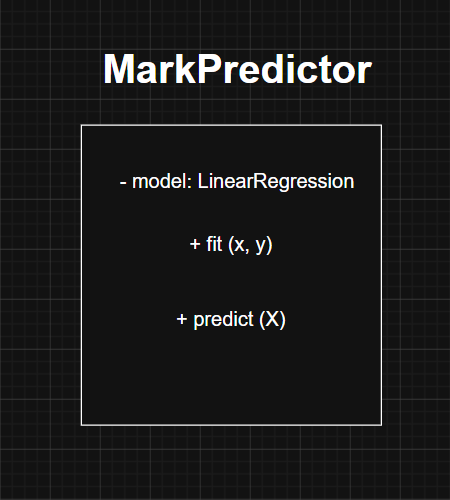

---
## Phase 5: Scaling Up to Level 2 (Multi-Subject)
**🎯 The Goal:** To achieve a Band 6, your AI needs to be smarter. You will now feed it two subjects simultaneously (Maths_Advanced and Physics). Because these subjects have different averages and variances, you MUST use `StandardScaler` to align them mathematically.

**📄 Documentation Task:** Write a paragraph explaining "Feature Scaling". Explain that if we don't scale the data, the AI might wrongly prioritize a subject just because the numbers are physically larger (e.g., if one subject was marked out of 500 and another out of 10).

**📊 PPT Slide Task:** Create a slide titled "Level 1 vs Level 2 AI". Put your Level 1 RMSE (single subject) next to your Level 2 RMSE (multi-subject). Explain why the error went down when the AI was given more context.

In [40]:
print("--- Training Level 2 AI (Multi-Subject) ---")

# Creates a new variable X2 that extracts BOTH 'Maths_Advanced' and 'Physics' from 'df_clean'.
X2 = df_clean[['Maths_Advanced', 'Physics']].values
# Runs train_test_split() again, this time using X2 and y.
X2_train, X2_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)


# Initialize a StandardScaler()
scaler = StandardScaler()
# Uses '.fit_transform()' to scale the X2_train data.
X2_train_scaled = scaler.fit_transform(X2_train)
# Uses ONLY '.transform()' to scale the X2_test data. (Do not train the test data!)
X2_test_scaled = scaler.transform(X2_test)

# Creates a new MarkPredictor() object.
my_ai = MarkPredictor()
# Trains on the scaled X2_train data.
my_ai.fit(X2_train_scaled, y_train)
# Predicts the scaled X2_test data and prints the final Level 2 RMSE.
final_predictor = my_ai.predict(X2_test_scaled)
final_mse  = mean_squared_error(y_test, final_predictor)
final_rmse = np.sqrt(final_mse)
print(f"Final Level 2 RMSE: {final_rmse}")
print(final_predictor)
print(X2_train)

--- Training Level 2 AI (Multi-Subject) ---
Final Level 2 RMSE: 5.521401366969644
[94.12827259 92.15050224 84.38779924 96.20961436 57.5962635 ]
[[45. 44.]
 [98. 98.]
 [72. 70.]
 [72. 72.]
 [52. 53.]
 [60. 59.]
 [54. 58.]
 [75. 75.]
 [43. 44.]
 [83. 82.]
 [44. 43.]
 [88. 91.]
 [68. 63.]
 [80. 79.]
 [84. 83.]
 [68. 67.]]


### Feature Scaling

It is very important that the data beign predicted is scaled as teh AI might unequally calculate between subjects due to the larger range of numbers. For example, a subject is being marked out of 500, whilst another is marked out of 10. Specifically, it sets a uniform range for each data calculated to set more accurate predictions. In the case of the AP, each subject should have one total score ranging from 0 to 100, with four assessment scores that add up to that score.

---
## Phase 6: The Ethics Audit (The 80% Rule)
**🎯 The Goal:** We must ensure our AI does not discriminate. You will group students into STEM (Physics > 70) and Humanities (Modern_History > 70) and check if the AI's predictions result in one group failing significantly more than the other.

**📄 Documentation Task:** Write an "Ethics Report" markdown cell. Search Google for the "Robodebt scandal" in Australia. Write a paragraph explaining how blind trust in automated systems causes harm, and justify why schools must always use a "Human-in-the-Loop" to review AI grades.

**📊 PPT Slide Task:** Create a slide titled "Bias & Ethics Audit". Display the pass rate percentages for Group A and Group B, and show your final Disparate Impact Ratio. Based on your results, give your final recommendation for the missing student's score!

In [ ]:
print("--- Running Bias Audit (80% Rule) ---")

# Creates group_a by filtering df_clean for students with 'Physics' > 70
group_a = df_clean[df_clean['Physics'] > 70]
# Creates group_b by filtering df_clean for students with 'Modern_History' > 70
group_b = df_clean[df_clean['Modern_History'] > 70]

# Calculates the pass rate for Group A. (Find the mean of rows where Software_Engineering_Final >= 50)
group_a_pass_rate = (group_a['Software_Engineering_Final'] >= 50).mean()
# Calculates the pass rate for Group B in the same way.
group_b_pass_rate = (group_b['Software_Engineering_Final'] >= 50).mean()

# Calculates the Disparate Impact Ratio by dividing the Group B pass rate by the Group A pass rate.
disparate_impact_ratio = group_b_pass_rate / group_a_pass_rate
print(f"Disparate Impact Ratio: {disparate_impact_ratio:.2f}")

# Writes an IF statement: If the ratio is less than 0.8, print a WARNING that bias was detected. Else, print that the audit passed.
if disparate_impact_ratio < 0.8:
    print("⚠️ WARNING: Bias detected! Disparate Impact Ratio is less than 0.8.")
else:
    print("✅ Bias audit passed! Disparate Impact Ratio is acceptable.")

--- Running Bias Audit (80% Rule) ---
Disparate Impact Ratio: 0.75
⚠️ WARNING: Bias detected! Disparate Impact Ratio is less than 0.8.


### Ethics Report

The blinded trust in automated systems can cause significant harm to users, which is why schools must have "Human-in-the-Loop" to chekc AI grades. It is evident that the Robodebt Scandal case involved an automated algorithm to match tax and welfare data, illegally issuing roughly half a million debt notices. It led to compensation and loss of goodwill due to its biased algorithmic results.

---
## Phase 7: Overfitting Check (Cross-Validation)
**🎯 The Goal:** Use K-Fold Cross-Validation to test the AI on 5 completely different slices of the data. This proves the AI hasn't just "memorized" your specific training data.

**📄 Documentation Task:** Define "Overfitting". Explain why an AI that memorizes past data will catastrophically fail when trying to predict marks for next year's Year 12 cohort.

In [ ]:
print("--- Cross-Validation Check ---")

# Scales entire X2 dataset using fit_transform()
X2_scaled = scaler.fit_transform(X2)
# Uses the cross_val_score() function. Pass in a LinearRegression(), and scaled data, and y. Set cv=5 and scoring='neg_root_mean_squared_error'.
cv_scores = cross_val_score(LinearRegression(), X2_scaled, y, cv=5, scoring='neg_root_mean_squared_error')
# Calculates the mean of the scores
cv_rmse = -cv_scores.mean()
# Prints the Cross-Validation RMSE.
print(f"Cross-Validation RMSE: {cv_rmse:.2f} marks")

--- Cross-Validation Check ---
Cross-Validation RMSE: 3.52 marks


### Overfitting

AI will ccatastrophically fail when predcting past marks for the next cohort because no tow cohorts are guaranteed to carry th same type of training data, more likely students of the next cohort may not be as successful as the cohort whose data the AI predicted.

---
## Phase 8: The Logic Gatekeeper
**🎯 The Goal:** Write a procedural safeguard (a hard-coded IF/ELSE function) to block unreliable students from using the AI system entirely.

**📄 Documentation Task:** Draw a Decision Tree flowchart showing how this gatekeeper works. Use a diamond shape for the IF condition (Attendance < 50%), and rectangles for the True/False outcomes. Embed the image below.

In [ ]:
print("--- Logic Gatekeeper ---")

# Defines a function called check_data_reliability(attendance_percentage)
def check_data_reliability(attendance_percentage):
    # TODO 2: Inside the function, write an IF statement: if attendance is less than 50.0, print "ACCESS DENIED" and return False.
    if attendance_percentage < 50.0:
        print("ACCESS DENIED")
        return False
    # TODO 3: Write the ELSE statement: print "ACCESS GRANTED" and return True.
    else:
        print("ACCESS GRANTED")
        return True

# Call the function to test a student with 45% attendance.
check_data_reliability(45.0)

# Call the function to test a student with 92% attendance.
check_data_reliability(92.0)

--- Logic Gatekeeper ---
ACCESS DENIED
ACCESS GRANTED


True

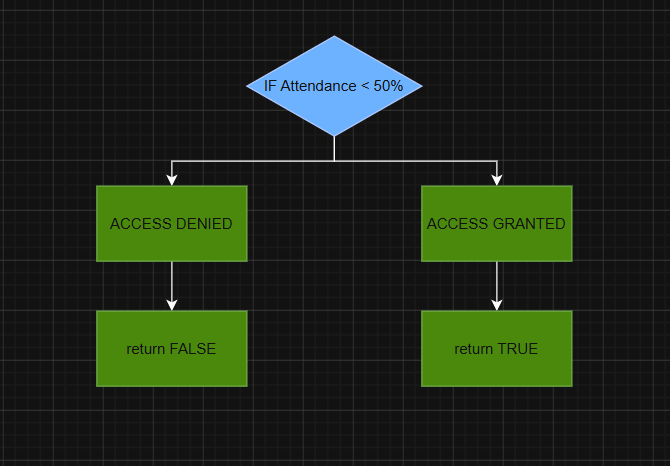

---
## 🏆 Extension: Neural Networks (Band 6 Target)
*(Optional)*: Can a deep learning "black box" beat your Linear Regression model?

**📄 Documentation Task:** Even if the Neural Network scores a better RMSE, explain why a school might still legally prefer to use Linear Regression. (Hint: Discuss the "Black Box" problem and why it is difficult to explain to a student *how* a Neural Network calculated their mark).

In [ ]:
from sklearn.neural_network import MLPRegressor
print("--- Extension: Neural Network Test ---")

# Initialize an MLPRegressor. Set hidden_layer_sizes=(16, 8), max_iter=1500, and random_state=42.
nn_model = MLPRegressor(hidden_layer_sizes=(16, 8), max_iter=1500, random_state=42)
# Train it on scaled X2_train data.
nn_model.fit(X2_train_scaled, y_train)
# Generate predictions for your scaled X2_test data.
nn_predictions = nn_model.predict(X2_test_scaled)
# Calculates the RMSE for the Neural Network.
nn_mse  = mean_squared_error(y_test, nn_predictions)
# Prints both Level 2 Linear RMSE and Neural Network RMSE side-by-side to declare a winner.
nn_rmse = np.sqrt(nn_mse)
print(f"Level 2 Linear RMSE: {final_rmse:.2f} marks")
print(f"Neural Network RMSE: {nn_rmse:.2f} marks")

--- Extension: Neural Network Test ---
Level 2 Linear RMSE: 5.52 marks
Neural Network RMSE: 2.68 marks


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1500) reached and the optimization hasn't converged yet.
  warnings.warn(
